### 1. 형태소 분석기를 이용하여 품사가 명사인 경우 해당 단어를 추출

In [1]:
# !cd ~/data && unzip synopsis.zip -d ~/work/weat/data/

In [2]:
import os

In [3]:
data_dir = os.path.join(os.getenv("HOME"), "work/weat/data")
file_name = os.path.join(data_dir, "synopsis.txt")

with open(file_name, 'r') as file:
    for i in range(20):
        print(file.readline(), end='')

사운드 엔지니어 상우(유지태 분)는 치매에 걸린 할머니(백성희 분)와
 젊은 시절 상처한 한 아버지(박인환 분), 고모(신신애 분)와 함께 살고 있다.
 어느 겨울 그는 지방 방송국 라디오 PD 은수(이영애 분)를 만난다.
 자연의 소리를 채집해 틀어주는 라디오 프로그램을 준비하는 은수는 상우와 녹음 여행을 떠난다.
 자연스레 가까워지는 두 사람은 어느 날, 은수의 아파트에서 밤을 보낸다.
 너무 쉽게 사랑에 빠진 두 사람... 상우는 주체할 수 없을 정도로 그녀에게 빨려든다.
 그러나 겨울에 만난 두 사람의 관계는 봄을 지나 여름을 맞이하면서 삐걱거린다.
 이혼 경험이 있는 은수는 상우에게 결혼할 생각이 없다며 부담스러운 표정을 내비친다.
 "어떻게 사랑이 변하니?..."라고 묻는 상우에게 은수는 그저 "헤어져" 라고 단호하게 말한다.
 영원히 변할 것 같지 않던 사랑이 변하고, 그 사실을 받아들이지 못하는 상우는 어찌 할 바를 모른다.
 은수를 잊지 못하는 상우는 미련과 집착의 감정을 이기지 못하고 서울과 강릉을 오간다.
유사 이래 연령, 성별, 빈부의 차이와 정치적인 입장을 불문하고 일거에 국민을 통합해 온 '애국심'이라는 성역에 일침을 가하는 다큐멘터리. 재작년 전국 민족민주 유가족협의회의 장기농성을 다룬 인상적인 다큐멘터리 <민들레>를 만들었던 독립영화집단 '빨간 눈사람'이 우리 사회 구석구석을 발빠르게 돌아다니며 애국심과 민족주의가 강요되는 현장을 발굴하여 카메라에 담았다. 박홍 서강대 명예총장, 이도형 '한국논단' 발행인, 축구해설자 신문선, 홍세화, 박노해 등 사회 각계의 '스타'들이 등장해 저마다의 확고한 신념을 성토한다. 감독 이경순과 최하동하는 이 작품을 위해 3년간 백여 명을 인터뷰했다고 한다. 2001 올해의 독립영화상 수상.
 민족과 국가란 공동체에서 부단히 권력과 부를 얻는 자, 나아가 민족과 국가란 공동체에서 얻은 신분과 부귀를 영원히 그의 자손에게 대물림하려는 자, 그래서 민족과 국가란 공동체를 부단히 유지해야만 하는 자, 따라서

In [76]:
# !sudo apt update
# !sudo apt install openjdk-17-jdk -y
# !echo 'export JAVA_HOME=$(dirname $(dirname $(readlink -f $(which java))))' >> ~/.bashrc
# !source ~/.bashrc

# !pip install konlpy


In [5]:
from konlpy.tag import Okt

okt = Okt()
tokenized = []

with open(file_name, 'r') as file:
    while True:
        line = file.readline()
        if not line : break
        # stem=True: 활용된 단어를 기본형으로 변환 ㅡ 어간 추출
        # 즉 동/형을 원형으로 복원 (ex: 먹었다 -> 먹다)
        words = okt.pos(line, stem=True, norm=True)
        res = []
        for w in words:
            if w[1] in ['Noun']:  # "Adjective", "Verb" 등을 포함할 수 도 있다
                res.append(w[0])  # 명사일 때 만 tokenized 에 저장하게 된다
        tokenized.append(res)

print('~')

~


In [6]:
print(len(tokenized))

71156


In [9]:
tokenized[:10]

[['사운드', '엔지니어', '상우', '유지태', '분', '치매', '할머니', '백성희', '분'],
 ['시절', '상처', '아버지', '박인환', '분', '고모', '신신애', '분', '살'],
 ['겨울', '그', '지방', '방송국', '라디오', '은수', '이영애', '분', '를'],
 ['자연', '소리', '채집', '라디오', '프로그램', '준비', '은수', '상우', '녹음', '여행'],
 ['두', '사람', '날', '은수', '아파트', '밤'],
 ['사랑', '두', '사람', '상우', '주체', '수', '정도', '그녀'],
 ['겨울', '만난', '두', '사람', '관계', '봄', '지나', '여름', '맞이', '삐걱', '거', '린다'],
 ['이혼', '경험', '은수', '상우', '결혼', '생각', '표정', '내비'],
 ['사랑', '상우', '은수', '단호', '말'],
 ['것', '사랑', '그', '사실', '상우', '어찌']]

### 2. 추출된 결과로 embedding model 만들기

In [7]:
from gensim.models import Word2Vec

In [8]:
# tokenized 에 담긴 데이터를 가지고 나만의 Word2Vec 을 생성
# 텍스트 데이터를 가지고 단어 임베딩을 학습하는 과정
model = Word2Vec(tokenized, vector_size=100, window=5, min_count=3, sg=0)
model.wv.most_similar(positive=['영화'])

[('작품', 0.8792148232460022),
 ('다큐멘터리', 0.8405707478523254),
 ('드라마', 0.82274329662323),
 ('영화로', 0.7904873490333557),
 ('형식', 0.7772055268287659),
 ('코미디', 0.77201908826828),
 ('주제', 0.7718796133995056),
 ('감동', 0.7634206414222717),
 ('실화', 0.7493172883987427),
 ('스토리', 0.7492300868034363)]

- vector_size = 임베딩 차원
- window = context 범위
- min_count = 최소 등장 횟수 -> 노이즈 제거, 학습 안정화
- sg : 모델 종류

### 3. TF-IDF 로 해당 데이터를 가장 잘 표현하는 단어 셋 만들기

In [12]:
import os
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from konlpy.tag import Okt

### TF-IDF를 적용했을 때의 문제점

- **단어의 중요도는 반영하지만 의미는 반영 X**

 - TF-IDF를 이용해도 중복된 단어를 잘 제거하면 여전히 유용한 방식

In [21]:
def read_token(file_name):
    okt = Okt()
    result = []
    with open(data_dir + '/' + file_name, 'r') as fread:
        print(file_name, '파일을 읽고 있습니다.')
        while True:
            line = fread.readline()
            if not line: break
            tokenlist = okt.pos(line, stem=True, norm=True)
            for word in tokenlist:
                if word[1] in ["Noun"]:#, "Adjective", "Verb"]:
                    result.append((word[0]))
    return ' '.join(result)


~


In [58]:
genre_txt = ['synopsis_SF.txt', 'synopsis_family.txt', 'synopsis_show.txt', 'synopsis_horror.txt', 'synopsis_etc.txt',
             'synopsis_documentary.txt', 'synopsis_drama.txt', 'synopsis_romance.txt', 'synopsis_musical.txt',
             'synopsis_mystery.txt', 'synopsis_crime.txt', 'synopsis_historical.txt', 'synopsis_western.txt',
             'synopsis_adult.txt', 'synopsis_thriller.txt', 'synopsis_animation.txt', 'synopsis_action.txt',
             'synopsis_adventure.txt', 'synopsis_war.txt', 'synopsis_comedy.txt', 'synopsis_fantasy.txt']

genre_name = ['SF', '가족', '공연', '공포(호러)', '기타', '다큐멘터리', '드라마', '멜로로맨스', '뮤지컬', '미스터리', '범죄', '사극', '서부극(웨스턴)',
         '성인물(에로)', '스릴러', '애니메이션', '액션', '어드벤처', '전쟁', '코미디', '판타지']
print("슝~")

슝~


In [59]:
genre = []
for file_name in genre_txt:
    genre.append(read_token(file_name))

synopsis_SF.txt 파일을 읽고 있습니다.
synopsis_family.txt 파일을 읽고 있습니다.
synopsis_show.txt 파일을 읽고 있습니다.
synopsis_horror.txt 파일을 읽고 있습니다.
synopsis_etc.txt 파일을 읽고 있습니다.
synopsis_documentary.txt 파일을 읽고 있습니다.
synopsis_drama.txt 파일을 읽고 있습니다.
synopsis_romance.txt 파일을 읽고 있습니다.
synopsis_musical.txt 파일을 읽고 있습니다.
synopsis_mystery.txt 파일을 읽고 있습니다.
synopsis_crime.txt 파일을 읽고 있습니다.
synopsis_historical.txt 파일을 읽고 있습니다.
synopsis_western.txt 파일을 읽고 있습니다.
synopsis_adult.txt 파일을 읽고 있습니다.
synopsis_thriller.txt 파일을 읽고 있습니다.
synopsis_animation.txt 파일을 읽고 있습니다.
synopsis_action.txt 파일을 읽고 있습니다.
synopsis_adventure.txt 파일을 읽고 있습니다.
synopsis_war.txt 파일을 읽고 있습니다.
synopsis_comedy.txt 파일을 읽고 있습니다.
synopsis_fantasy.txt 파일을 읽고 있습니다.


In [61]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(genre)

print(X.shape)

(21, 42191)


## **유사한 거 중복 제거**

In [62]:
def is_similar(word, selected, model,threshold=0.8):
    for w in selected:
        if model.wv.similarity(word,w) > threshold:
            return True
    return False

In [66]:
m = [X[i].tocoo() for i in range(X.shape[0])]

w = [[[i, j] for i, j in zip(mm.col, mm.data)] for mm in m]

for i in range(len(w)):
    w[i].sort(key=lambda x: x[1], reverse=True)
attributes = []
for i in range(len(w)):
    print(genre_name[i], end=': ')
    attr = []
    j = 0

    # 상위 15개 단어를 뽑을 때 까지
    while (len(attr) < 15):

        word = vectorizer.get_feature_names_out()[w[i][j][0]]

        if word in model.wv:
            if not is_similar(word, attr, model):
                attr.append(word)
                print(word, end=', ')
        
        j+=1
    attributes.append(attr)
    print()

SF: 위해, 자신, 지구, 시작, 사람, 인간, 미래, 그녀, 로봇, 세계, 모든, 박사, 우주선, 존재, 세상, 
가족: 엄마, 가족, 영화제, 자신, 위해, 친구, 아주르, 아버지, 시작, 그녀, 국제, 마을, 할머니, 사람, 아이, 
공연: 오페라, 사랑, 토스카, 자신, 그녀, 프레, 위해, 왕자, 아리아, 무대, 도시, 시작, 결혼, 사람, 레오, 
공포(호러): 시작, 위해, 사람, 자신, 친구, 그녀, 사건, 공포, 발견, 죽음, 마을, 가족, 악령, 남자, 좀비, 
기타: 영화제, 국제, 서울, 단편, 영화, 자신, 사람, 이야기, 그녀, 남자, 위해, 시작, 사랑, 대한, 친구, 
다큐멘터리: 영화제, 영화, 다큐, 국제, 사람, 이야기, 대한, 자신, 감독, 위해, 서울, 우리, 시작, 세계, 통해, 
드라마: 자신, 영화제, 그녀, 사람, 사랑, 영화, 위해, 시작, 국제, 남자, 친구, 이야기, 엄마, 아버지, 가족, 
멜로로맨스: 그녀, 사랑, 자신, 시작, 남편, 남자, 사람, 친구, 섹스, 위해, 마음, 결혼, 서로, 관계, 엄마, 
뮤지컬: 뮤지컬, 사랑, 에스메랄다, 그녀, 음악, 영화, 자신, 니웨, 영화제, 시작, 샤오캉, 위해, 최고, 애니, 공연, 
미스터리: 사건, 그녀, 시작, 자신, 위해, 사람, 발견, 사고, 진실, 죽음, 기억, 살인, 친구, 아내, 아이, 
범죄: 사건, 위해, 자신, 경찰, 시작, 그녀, 범죄, 사람, 남자, 모든, 살해, 발견, 한길수, 계획, 작전, 
사극: 조선, 위해, 시작, 사랑, 자신, 아가멤논, 그녀, 사람, 운명, 최고, 전쟁, 신재효, 세자, 권력, 사건, 
서부극(웨스턴): 서부, 보안관, 위해, 벌린, 그레이프바인, 헨리, 마을, 자신, 아이, 시작, 태구, 분노, 버질, 가족, 사람, 
성인물(에로): 그녀, 남편, 마사지, 자신, 관계, 영화, 남자, 위해, 시작, 마음, 사랑, 에피소드, 그린, 다시, 자위, 
스릴러: 자신, 그녀, 사건, 시작, 위해, 사람, 살인,

### 4. embedding model 과 단어 셋으로 WEAT score 구해보기

- target_X = art
- target_Y = gen
- attribute_A = 'Drama'
- attribute_B = 'Action'

$$
\frac{
\mathrm{mean}_{x \in X} s(x, A, B)
-
\mathrm{mean}_{y \in Y} s(y, A, B)
}{
\mathrm{std}_{w \in X \cup Y} s(w, A, B)
}
$$

- 두 target 집단 (X,Y)이 attribute(A,B)에 얼마나 다르게 연관되는지를 표준화해서 측정하는 값
- mean_x : x집단이 A,B 중 어디에 더 가까운지 평균
- mean_y : y집단이 A,B 중 어디에 더 가까운지 평균
- mean_x - mean_y : x와 y가 얼마나 다르게 행동하는지
- /std_dev : 두 집단 차이를 표준화

In [67]:

def cos_sim(i,j):
    return np.dot(i, j.T)/(np.linalg.norm(i)*np.linalg.norm(j))

def s(w, A, B):
    c_a = cos_sim(w, A)
    c_b = cos_sim(w, B)
    mean_A = np.mean(c_a, axis=-1)
    mean_B = np.mean(c_b, axis=-1)
    return mean_A - mean_B

def weat_score(X, Y, A, B):

    s_X = s(X, A, B)
    s_Y = s(Y, A, B)

    mean_X = np.mean(s_X)
    mean_Y = np.mean(s_Y)

    std_dev = np.std(np.concatenate([s_X, s_Y], axis=0))

    return  (mean_X-mean_Y)/std_dev

In [68]:
matrix = [[0 for _ in range(len(genre_name))] for _ in range(len(genre_name))]

In [70]:
X = np.array([model.wv[word] for word in target_art])
Y = np.array([model.wv[word] for word in target_gen])

for i in range(len(genre_name)-1):
    for j in range(i+1, len(genre_name)):
        A = np.array([model.wv[word] for word in attributes[i]])
        B = np.array([model.wv[word] for word in attributes[j]])
        matrix[i][j] = weat_score(X,Y,A,B)
print('~')

~


In [74]:
# for i in range(len(genre_name)-1):
#     for j in range(i+1, len(genre_name)):
#         print(genre_name[i], genre_name[j], matrix[i][j])

In [72]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import seaborn as sns

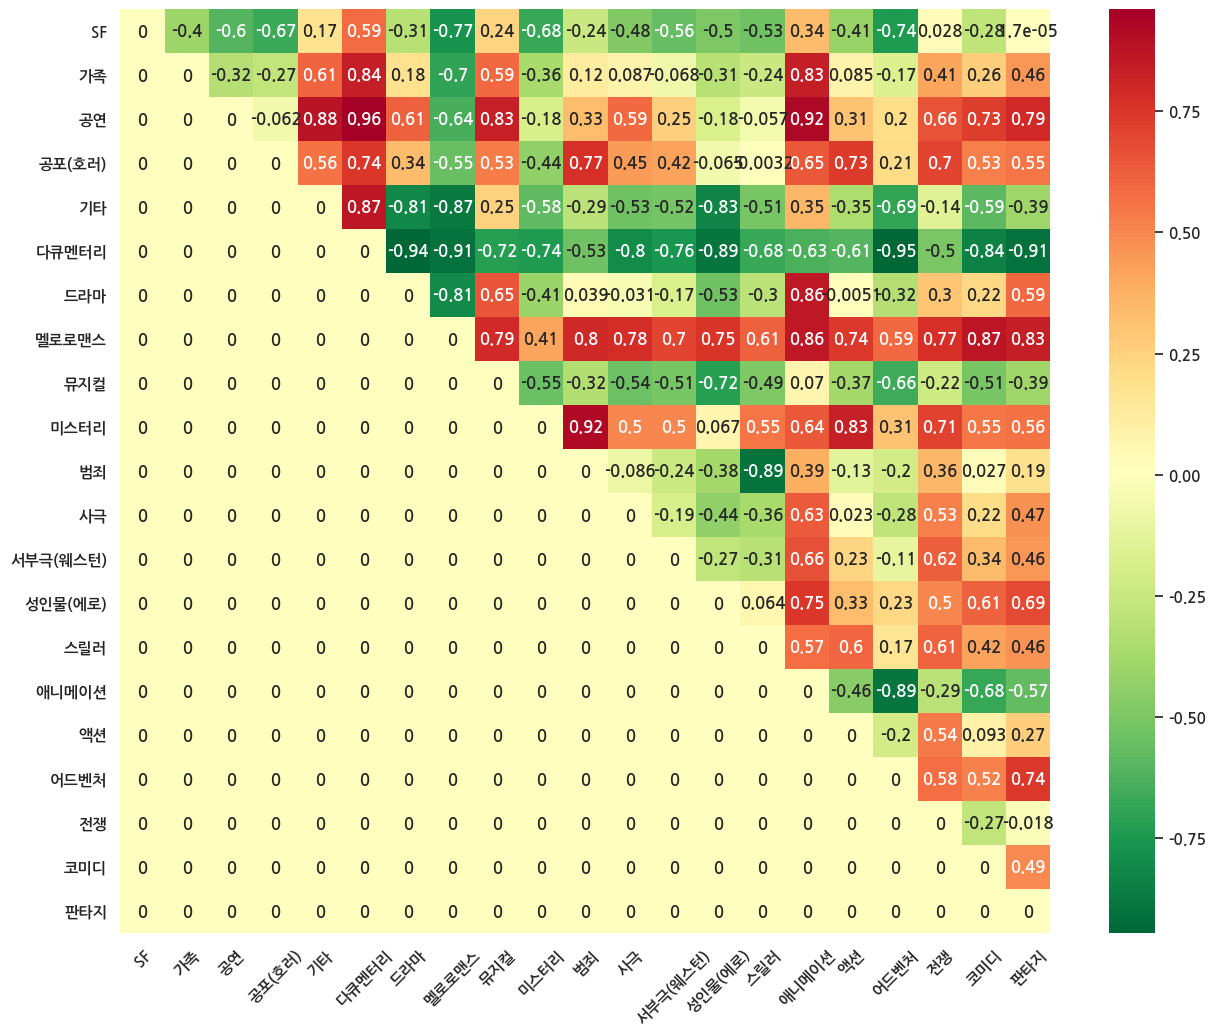

In [75]:
np.random.seed(0)
# 마이너스 부호

plt.figure(figsize=(15, 12))  # (가로, 세로) 크게 조절

ax = sns.heatmap(
    matrix,
    xticklabels=genre_name,
    yticklabels=genre_name,
    annot=True,
    cmap='RdYlGn_r'
)

plt.xticks(rotation=45)  # x축 글자 기울이기
plt.yticks(rotation=0)

plt.show()

### 회고

-행(ROW)기준 해석
- 미스터리 장르는 범죄(0.92) / 스릴러(0.83) 과 높은 유사도를 보이며, 이는 해당 장르들이 사건이 공통괸 특성을 공유하기 때문이다
- 다큐멘터리가 다른 장르들과 유사하지 않다고 나온다
- 멜로로멘스는 미스터리랑 거리가 가장 낮고(0.41), 애니메이션이랑 가장 거리가 가깝게(0.87) 나온다.
- SF가 현실기반 다큐멘러리와 가장 양의 값을 가지는게 우리가 생각하는 거랑 다르게 나온다


- 몇몇 결과가 직관과 다르게 나왔다. 이는 실제 의미 관계가 왜곡 되었다라고 생각한다. 해결하기 위해서 유사도가 높은 단어는 제외했는데, 생각보다 효과가 없었던 것 같다

- NLP 는 이미지랑 다르게 처리하는 과정이 익숙하지 않다. 퍼실님은 NLP가 CV보다 재밌다고 하셔서 어디서 재미를 느끼셨는지 이해해 보고 싶어 포인트를 찾으려고 했지만, 실패했다.